In [ ]:
import os
from pathlib import Path

cache_dir = Path('/tmp/matplotlib_cache')
cache_dir.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(cache_dir)

import matplotlib
import matplotlib.pyplot as plt

print('matplotlib OK:', matplotlib.__version__)

# Análisis Exploratorio de Datos (EDA)

In [6]:
import warnings
warnings.filterwarnings('ignore') 

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sps 

# Cargar el Dataset
df = pd.read_csv('data/retailmax.csv')

ModuleNotFoundError: No module named 'matplotlib'

# 1. ¿Cuál es la distribución de edades de los clientes?

In [5]:
sps.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))
sps.histplot(df['Age'], bins=15, kde=True, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades de los Clientes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f} años')
plt.axvline(df['Age'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["Age"].median():.1f} años')
plt.legend(fontsize=11)
plt.show()

NameError: name 'sps' is not defined

# 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

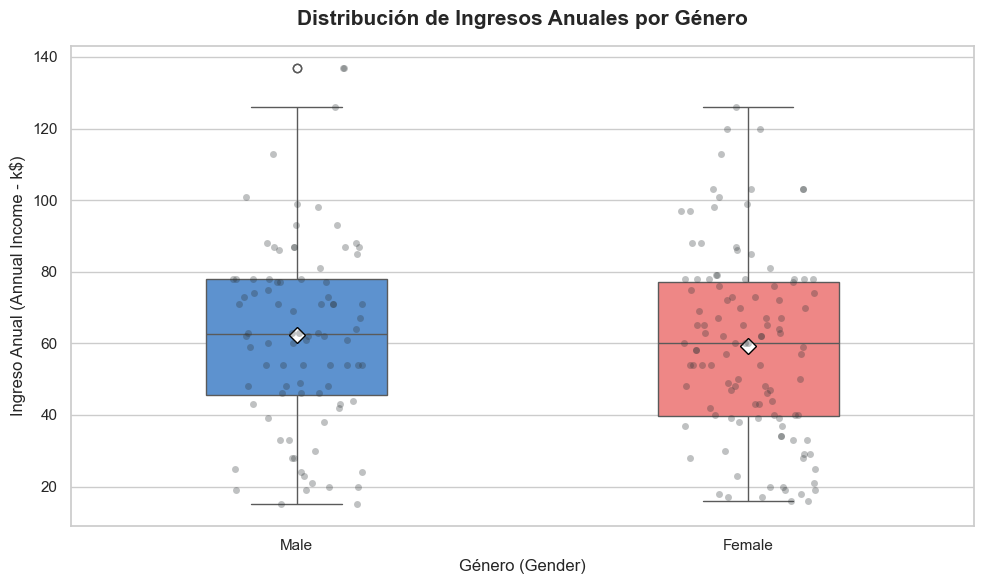

In [ ]:
plt.figure(figsize=(10, 6))

# Gráfico de caja (boxplot) con strip plot superpuesto para ver la distribución individual
sps.boxplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    width=0.4,
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Mostrar los puntos individuales de datos de manera sutil
sps.stripplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    color='#2d3436', 
    alpha=0.3, 
    jitter=0.15, 
    size=5
)

plt.title('Distribución de Ingresos Anuales por Género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género (Gender)', fontsize=12)
plt.ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de ingresos anuales entre hombres y mujeres, observamos que **no existen diferencias drásticas**, aunque sí se aprecian ligeras variaciones a favor del grupo masculino:

1. **Promedio (Media) y Mediana:**
   - Los **hombres** tienen un ingreso anual promedio de **62.23 k$** y una mediana de **62.50 k$**.
   - Las **mujeres** tienen un ingreso anual promedio de **59.25 k$** y una mediana de **60.00 k$**.
   - Esto representa una ligera diferencia de **~2.98 k$ en la media** y **2.50 k$ en la mediana** a favor de los hombres.

2. **Dispersión y Límites:**
   - La dispersión (desviación estándar) es sumamente similar en ambos grupos: **26.64 k$** para hombres y **26.01 k$** para mujeres.
   - Los rangos intercuartílicos y las cajas en el gráfico muestran que el 50% central de la población se encuentra en rangos muy similares, aunque el límite inferior del 25% de los hombres (45.5 k$) es ligeramente mayor al de las mujeres (39.75 k$).
   - El ingreso máximo registrado pertenece a un hombre con **137 k$**, mientras que el de las mujeres es de **126 k$**.

**Conclusión:** Aunque estadísticamente los hombres muestran ingresos ligeramente superiores en términos de medidas de tendencia central (media y mediana) y valores máximos, las distribuciones se superponen en gran medida. Esto sugiere que **el género no es un factor determinante o altamente diferenciador** para el nivel de ingresos en este conjunto de datos.

# 3. ¿Cómo se distribuye la puntuación de gastos entre los diferentes rangos de edades?

In [ ]:
plt.figure(figsize=(10, 6))

sps.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    hue='Gender',
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    alpha=0.8,
    s=80
)

plt.title('Relación entre la Edad y la Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score 1-100)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de la puntuación de gastos (`Spending Score (1-100)`) en función de la edad (`Age`), podemos extraer conclusiones muy claras y valiosas sobre el comportamiento de los clientes:

1. **Límite de Edad para Altos Consumidores:**
   - Se observa una clara barrera alrededor de los **40 años**. Prácticamente **ningún cliente mayor de 40 años supera una puntuación de gasto de 60**.
   - La gran mayoría de los clientes de más de 40 años se concentra en un rango de puntuación moderado y bajo (entre 1 y 60 puntos), con una media que ronda los **32-34 puntos**.

2. **Comportamiento en Clientes Jóvenes (< 40 años):**
   - Los clientes de entre 18 y 40 años muestran una dispersión mucho mayor y son los únicos que alcanzan puntuaciones de gastos sobresalientes (entre 60 y 100 puntos).
   - En este segmento joven, se aprecian claramente dos grupos bien diferenciados: uno de perfil muy ahorrador/moderado (puntuaciones bajas) y otro de perfil altamente consumidor (puntuaciones que van de 60 a 99 puntos).

**Conclusión:** La edad es un factor altamente segmentador en este conjunto de datos. Mientras que los clientes jóvenes (< 40 años) presentan un grupo con potencial de compra sumamente elevado, el segmento de mayor edad (>= 40 años) exhibe un comportamiento de gasto mucho más moderado y homogéneo, sin superar nunca la franja alta de puntuación.